In [1]:
!pip install --upgrade yfinance pandas-datareader

In [2]:
#Imports
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

/tmp/ipython-input-1600640707.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('NFLX', start='2010-04-01', end='2022-04-25')
[*********************100%***********************]  1 of 1 completed


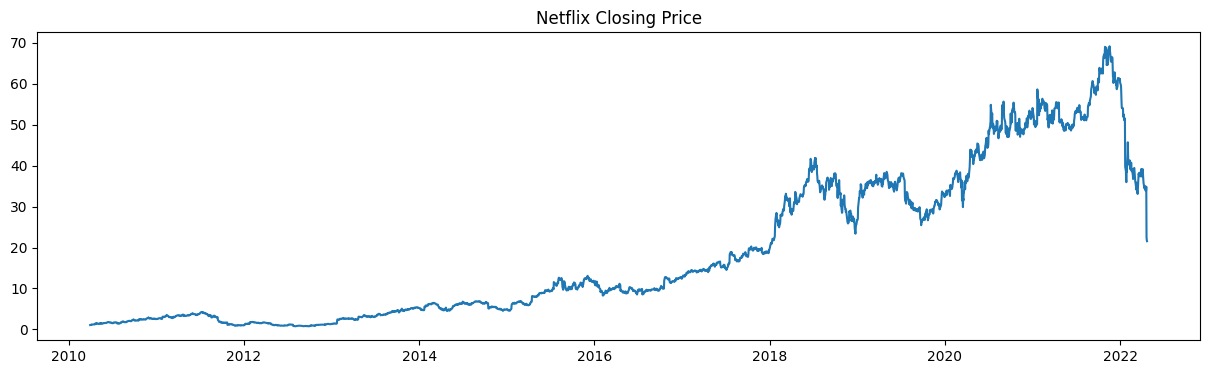

In [3]:
#Download Stock Data
df = yf.download('NFLX', start='2010-04-01', end='2022-04-25')
df = df[['Close']]
plt.figure(figsize=(15,4))
plt.plot(df)
plt.title('Netflix Closing Price')
plt.show()

In [4]:
#Normalize Data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df.values)

In [5]:
#Dataset Preparation
class StockDataset(Dataset):
    def __init__(self, data, time_step=100):
        self.X, self.y = [], []
        for i in range(len(data) - time_step - 1):
            self.X.append(data[i:i+time_step])
            self.y.append(data[i+time_step])
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

time_step = 100
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

train_dataset = StockDataset(train_data, time_step)
test_dataset = StockDataset(test_data, time_step)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
#Define RNN Variants
class StockRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, rnn_type='RNN', num_layers=1, dropout=0.2):
        super(StockRNN, self).__init__()
        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size

        if rnn_type == 'RNN':
            self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                              batch_first=True, dropout=dropout if num_layers>1 else 0)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers,
                               batch_first=True, dropout=dropout if num_layers>1 else 0)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size, hidden_size, num_layers,
                              batch_first=True, dropout=dropout if num_layers>1 else 0)
        elif rnn_type == 'BiLSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers,
                               batch_first=True, dropout=dropout if num_layers>1 else 0,
                               bidirectional=True)
        else:
            raise ValueError("Unsupported rnn_type")

        self.fc = nn.Linear(hidden_size*(2 if rnn_type=='BiLSTM' else 1), 1)

    def forward(self, x):
        if self.rnn_type in ['LSTM','BiLSTM']:
            out, (hn, cn) = self.rnn(x)
        else:
            out, hn = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [7]:
#Training
def train_model(model, train_loader, test_loader, epochs=100, lr=0.0005, patience=15, device='cpu'):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    best_val_loss = np.inf
    trigger_times = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for X_val, y_val in test_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                y_pred = model(X_val)
                val_batch_losses.append(criterion(y_pred, y_val).item())
        val_loss = np.mean(val_batch_losses)
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
            best_model_state = model.state_dict()
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"Early stopping at epoch {epoch+1}, best val loss: {best_val_loss:.6f}")
                model.load_state_dict(best_model_state)
                break

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses

In [8]:
# Hyperparameter Grid
hyperparams = {
    'hidden_size': [50, 100],
    'num_layers': [1, 2],
    'lr': [0.0005, 0.0003]
}

In [9]:
#Compare Models
models_list = ['RNN', 'LSTM', 'GRU', 'BiLSTM']
results = {}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

for m in models_list:
    print(f"\nTraining {m}...")
    best_val = np.inf
    best_params = None
    best_model_state = None
    for hidden_size in hyperparams['hidden_size']:
        for num_layers in hyperparams['num_layers']:
            for lr in hyperparams['lr']:
                model = StockRNN(rnn_type=m, hidden_size=hidden_size, num_layers=num_layers).to(device)
                train_losses, val_losses = train_model(model, train_loader, test_loader, epochs=100, lr=lr, patience=10, device=device)
                if val_losses[-1] < best_val:
                    best_val = val_losses[-1]
                    best_params = {'hidden_size': hidden_size, 'num_layers': num_layers, 'lr': lr}
                    best_model_state = model.state_dict()
    # Load best model
    model = StockRNN(rnn_type=m, hidden_size=best_params['hidden_size'], num_layers=best_params['num_layers']).to(device)
    model.load_state_dict(best_model_state)
    results[m] = {'model': model, 'params': best_params, 'train_loss': train_losses, 'val_loss': val_losses}
    print(f"{m} best params: {best_params}")

Using device: cuda

Training RNN...
Epoch 10/100, Train Loss: 0.000139, Val Loss: 0.004231
Epoch 20/100, Train Loss: 0.000119, Val Loss: 0.001905
Epoch 30/100, Train Loss: 0.000082, Val Loss: 0.001450
Epoch 40/100, Train Loss: 0.000084, Val Loss: 0.001290
Epoch 50/100, Train Loss: 0.000067, Val Loss: 0.000768
Epoch 60/100, Train Loss: 0.000062, Val Loss: 0.001063
Early stopping at epoch 67, best val loss: 0.000636
Epoch 10/100, Train Loss: 0.000139, Val Loss: 0.006770
Epoch 20/100, Train Loss: 0.000129, Val Loss: 0.003614
Epoch 30/100, Train Loss: 0.000111, Val Loss: 0.002094
Epoch 40/100, Train Loss: 0.000094, Val Loss: 0.001407
Epoch 50/100, Train Loss: 0.000082, Val Loss: 0.001028
Early stopping at epoch 57, best val loss: 0.000943
Epoch 10/100, Train Loss: 0.000228, Val Loss: 0.005872
Early stopping at epoch 11, best val loss: 0.003860
Epoch 10/100, Train Loss: 0.000276, Val Loss: 0.008170
Early stopping at epoch 11, best val loss: 0.004249
Epoch 10/100, Train Loss: 0.000116, Val L

In [10]:
#Predictions and Metrics
rmse_scores = {}
mae_scores = {}
predictions = {}

for m in models_list:
    model = results[m]['model']
    model.eval()
    y_true_list, y_pred_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            y_true_list.append(y_batch.cpu().numpy())
            y_pred_list.append(y_pred.cpu().numpy())
    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1,1))
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1,1))

    # Calculate RMSE by taking the square root of MSE
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    rmse_scores[m] = rmse
    mae_scores[m] = mae
    predictions[m] = (y_true_inv, y_pred_inv)

    print(f"{m} - RMSE: {rmse_scores[m]:.2f}, MAE: {mae_scores[m]:.2f}")

RNN - RMSE: 1.49, MAE: 1.02
LSTM - RMSE: 3.56, MAE: 2.79
GRU - RMSE: 1.57, MAE: 1.08
BiLSTM - RMSE: 2.10, MAE: 1.63


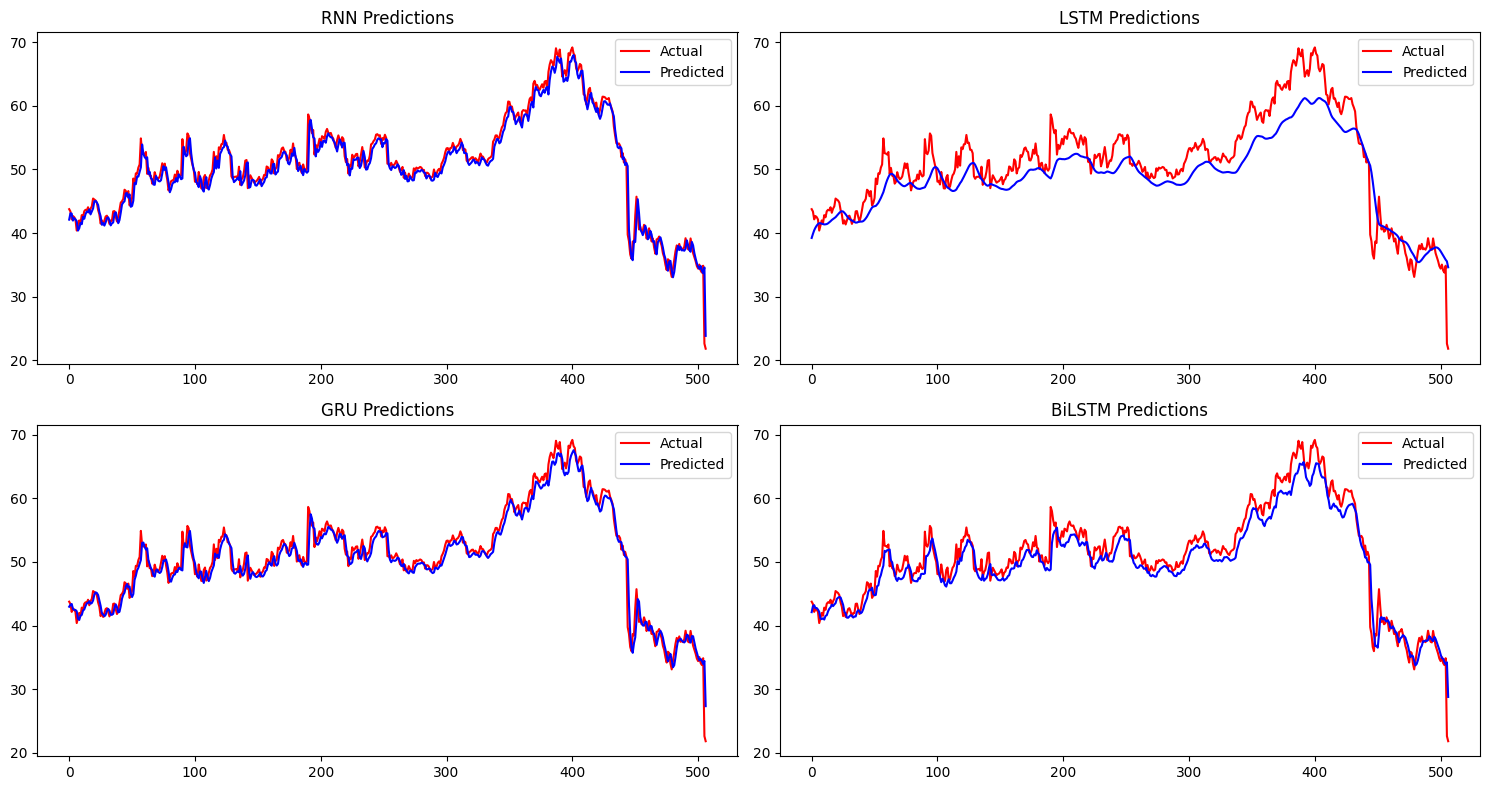

In [11]:
#Plot Predictions
plt.figure(figsize=(15,8))
for i, m in enumerate(models_list):
    plt.subplot(2,2,i+1)
    y_true_inv, y_pred_inv = predictions[m]
    plt.plot(y_true_inv, label='Actual', color='r')
    plt.plot(y_pred_inv, label='Predicted', color='b')
    plt.title(f"{m} Predictions")
    plt.legend()
plt.tight_layout()
plt.show()